In [6]:
# Fig3: Dissecting the structural basis of burst and sustained dynamics through domain swapping
# Analysis to identify the three behavioral groups from the paper:
# 1. Slow-sustained: prolonged motion >12 h, velocity 10-50 nm/s
# 2. Fast-burst: brief motion < 2 h, velocity 50-1000 nm/s  
# 3. Multiphase: concentration-dependent transitions

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [7]:
# Load and prepare data for behavioral classification
df = pd.read_csv('../../../Thomson Lab Dropbox/David Larios/activedrops/main/all/motor_dataset.csv')

print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nUnique proteins: {sorted(df['protein'].unique())}")

# Filter to chimeras A-H
chimeras = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
df_chimeras = df[df['protein'].isin(chimeras)].copy()

print(f"\nFiltered to chimeras A-H: {len(df_chimeras)} rows")
print(f"Chimeras present: {sorted(df_chimeras['protein'].unique())}")

# Sort by protein, DNA nM, time (s)
df_chimeras = df_chimeras.sort_values(['protein', 'DNA nM', 'time (s)']).reset_index(drop=True)

df_chimeras.head()

Total rows: 243921
Columns: ['condition', 'subcondition', 'time (s)', 'Time_min', 'Time_h', 'Mean Intensity', 'Protein Concentration_ng_ul', 'Protein Concentration_nM', 'Unnamed: 0', 'frame', 'x [m]_mean', 'y [m]_mean', 'u [m/s]_mean', 'v [m/s]_mean', 'data type [-]_mean', 'vorticity [1/s]_mean', 'velocity magnitude [m/s]_mean', 'divergence [1/s]_mean', 'dcev [1]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'vector direction [degrees]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'time (min)', 'time (h)', 'protein', 'DNA nM', 'Number of Protein Molecules', 'Rate of Change of Protein Molecules per Second', 'Translation Rate aa_s', 'kDa', 'Translation Rate [nM/s]']

Unique proteins: ['A', 'AcSu2', 'AdPa', 'B', 'BleSto', 'C', 'D', 'DiPu', 'E', 'F', 'G', 'H', 'HeAl', 'Kif5', 'NaGr', 'ThTr', 'Unc']

Filtered to chimeras A-H: 68487 rows
Chimeras present: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


,condition,subcondition,time (s),Time_min,Time_h,Mean Intensity,Protein Concentration_ng_ul,Protein Concentration_nM,Unnamed: 0,frame,...,work [J]_mean,time (min),time (h),protein,DNA nM,Number of Protein Molecules,Rate of Change of Protein Molecules per Second,Translation Rate aa_s,kDa,Translation Rate [nM/s]
0,K401_1p25nM,Rep1,0.0,0.0,0.000000,179.914233,0.000000,0.000000,NaN,NaN,...,NaN,NaN,NaN,A,1.25,NaN,NaN,NaN,NaN,0.003183
1,K401_1p25nM,Rep1,600.0,10.0,0.166667,181.127909,0.051565,1.909813,NaN,NaN,...,NaN,NaN,NaN,A,1.25,NaN,NaN,NaN,NaN,0.002563
2,K401_1p25nM,Rep1,1200.0,20.0,0.333333,181.868650,0.083037,3.075428,NaN,NaN,...,NaN,NaN,NaN,A,1.25,NaN,NaN,NaN,NaN,0.002366
3,K401_1p25nM,Rep1,1800.0,30.0,0.500000,182.932426,0.128233,4.749361,NaN,NaN,...,NaN,NaN,NaN,A,1.25,NaN,NaN,NaN,NaN,0.002877
4,K401_1p25nM,Rep1,2400.0,40.0,0.666667,184.062858,0.176261,6.528183,NaN,NaN,...,NaN,NaN,NaN,A,1.25,NaN,NaN,NaN,NaN,0.003105


In [8]:
# Task 2: Per (motor, DNA) summary metrics

# Define velocity threshold for motion detection
VELOCITY_THRESHOLD = 5e-8  # m/s

def compute_per_motor_dna_summary(group):
    """Compute summary metrics for a single (motor, DNA) group"""
    # Forward fill missing values for key columns
    key_cols = ['velocity magnitude [m/s]_mean', 'power [W]_mean', 
                'work [J]_mean', 'Protein Concentration_nM']
    for col in key_cols:
        if col in group.columns:
            group[col] = group[col].ffill()
    
    # Get time in hours
    if 'time (h)' in group.columns:
        time_h = group['time (h)'].values
    elif 'Time_h' in group.columns:
        time_h = group['Time_h'].values
    else:
        time_h = group['time (s)'].values / 3600
    
    # Velocity metrics
    vel_col = 'velocity magnitude [m/s]_mean'
    if vel_col not in group.columns:
        return None
    
    velocity = group[vel_col].fillna(0).values
    
    # Onset: first time velocity exceeds threshold
    above_threshold = velocity > VELOCITY_THRESHOLD
    if above_threshold.any():
        onset_idx = np.where(above_threshold)[0][0]
        onset_h = time_h[onset_idx]
        
        # Duration: total time above threshold
        # Calculate duration as time from onset to last point above threshold
        above_indices = np.where(above_threshold)[0]
        if len(above_indices) > 0:
            last_above_idx = above_indices[-1]
            duration_h = time_h[last_above_idx] - time_h[onset_idx]
        else:
            duration_h = 0
    else:
        onset_h = np.nan
        duration_h = 0
    
    max_vel = np.nanmax(velocity) if len(velocity) > 0 else 0
    
    # Power metrics
    power_col = 'power [W]_mean'
    if power_col in group.columns:
        power = group[power_col].fillna(0).values
        max_power = np.nanmax(power) if len(power) > 0 else 0
        max_power_idx = np.nanargmax(power) if len(power) > 0 else 0
        time_max_power_h = time_h[max_power_idx] if len(time_h) > 0 else np.nan
    else:
        max_power = 0
        time_max_power_h = np.nan
        max_power_idx = 0
    
    # Work metrics
    work_col = 'work [J]_mean'
    if work_col in group.columns:
        work = group[work_col].fillna(0).values
        total_work = work[-1] if len(work) > 0 else 0
    else:
        total_work = 0
    
    # Protein concentration metrics
    prot_col = 'Protein Concentration_nM'
    if prot_col in group.columns:
        prot_conc = group[prot_col].fillna(0).values
        prot_final_nM = prot_conc[-1] if len(prot_conc) > 0 else 0
        prot_at_max_power_nM = prot_conc[max_power_idx] if len(prot_conc) > max_power_idx else 0
    else:
        prot_final_nM = 0
        prot_at_max_power_nM = 0
    
    # DNA concentration
    dna_nM = group['DNA nM'].iloc[0] if 'DNA nM' in group.columns else np.nan
    
    # Gene to protein gain
    gene2prot_gain = prot_final_nM / dna_nM if dna_nM > 0 else np.nan
    
    # Power and velocity per protein
    power_per_prot = max_power / prot_final_nM if prot_final_nM > 0 else np.nan
    vel_per_prot = max_vel / prot_final_nM if prot_final_nM > 0 else np.nan
    
    # Translation rate metrics
    trans_rate_col = 'Translation Rate [nM/s]'
    if trans_rate_col in group.columns:
        trans_rate = group[trans_rate_col].fillna(0).values
        trans_rate_at_max_power = trans_rate[max_power_idx] if len(trans_rate) > max_power_idx else 0
        
        # Early translation rate (first 6 hours)
        early_mask = time_h <= 6
        if early_mask.any():
            avg_trans_early = np.nanmean(trans_rate[early_mask])
        else:
            avg_trans_early = 0
    else:
        trans_rate_at_max_power = 0
        avg_trans_early = 0
    
    return pd.Series({
        'onset_h': onset_h,
        'duration_h': duration_h,
        'max_vel': max_vel,
        'max_power': max_power,
        'total_work': total_work,
        'prot_final_nM': prot_final_nM,
        'gene2prot_gain': gene2prot_gain,
        'power_per_prot': power_per_prot,
        'vel_per_prot': vel_per_prot,
        'time_max_power_h': time_max_power_h,
        'prot_at_max_power_nM': prot_at_max_power_nM,
        'trans_rate_at_max_power': trans_rate_at_max_power,
        'avg_trans_early': avg_trans_early
    })

# Compute summary for each (protein, DNA nM) combination
summary_per_motor_dna = df_chimeras.groupby(['protein', 'DNA nM']).apply(
    compute_per_motor_dna_summary
).reset_index()

print(f"Computed summaries for {len(summary_per_motor_dna)} (motor, DNA) combinations")
summary_per_motor_dna.head(10)


Computed summaries for 64 (motor, DNA) combinations


,protein,DNA nM,onset_h,duration_h,max_vel,max_power,total_work,prot_final_nM,gene2prot_gain,power_per_prot,vel_per_prot,time_max_power_h,prot_at_max_power_nM,trans_rate_at_max_power,avg_trans_early
0,A,1.25,NaN,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,446.604957,357.283966,0.000000e+00,0.000000e+00,NaN,0.000000,0.003183,0.000000
1,A,2.50,NaN,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,538.265395,215.306158,0.000000e+00,0.000000e+00,NaN,0.000000,0.003447,0.000000
2,A,5.00,NaN,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,752.359718,150.471944,0.000000e+00,0.000000e+00,NaN,0.000000,0.003604,0.000000
3,A,10.00,NaN,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1031.769485,103.176949,0.000000e+00,0.000000e+00,NaN,0.000000,0.003336,0.000000
4,A,20.00,NaN,0.000000,3.098720e-09,1.418586e-22,1.041382e-19,1314.637399,65.731870,1.079070e-25,2.357091e-12,20.800000,766.134081,0.000000,0.001422
5,A,40.00,NaN,0.000000,9.833545e-09,2.807839e-21,9.127411e-19,1286.403065,32.160077,2.182705e-24,7.644217e-12,19.916667,706.412954,0.000000,0.003382
6,A,80.00,NaN,0.000000,2.469055e-08,5.585212e-20,1.449111e-17,1318.692831,16.483660,4.235416e-23,1.872350e-11,17.966667,526.666850,0.000000,0.001155
7,A,160.00,15.25,4.466667,5.441118e-08,2.505042e-19,5.711638e-17,1384.061132,8.650382,1.809922e-22,3.931270e-11,15.250000,491.994009,0.000000,0.000681
8,B,1.25,NaN,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1215.277464,972.221971,0.000000e+00,0.000000e+00,NaN,0.000000,0.000000,0.000000
9,B,2.50,NaN,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1573.669920,629.467968,0.000000e+00,0.000000e+00,NaN,0.000000,0.010262,0.000000


In [9]:
# Task 3: Motor-level summary (per protein)

# Module mapping
module_map = {
    'A': 'MMM',
    'B': 'BMM',
    'C': 'MBM',
    'D': 'BBM',
    'E': 'MMB',
    'F': 'BMB',
    'G': 'MBB',
    'H': 'BBB'
}

def compute_motor_summary(motor_summary):
    """Compute summary metrics for a single motor across all DNA concentrations"""
    motor = motor_summary['protein'].iloc[0]
    
    # Max power and associated metrics
    max_power_idx = motor_summary['max_power'].idxmax()
    max_power = motor_summary.loc[max_power_idx, 'max_power']
    DNA_at_max_power = motor_summary.loc[max_power_idx, 'DNA nM']
    prot_at_max_power = motor_summary.loc[max_power_idx, 'prot_at_max_power_nM']
    time_at_max_power = motor_summary.loc[max_power_idx, 'time_max_power_h']
    
    # Max work
    max_work_idx = motor_summary['total_work'].idxmax()
    max_work = motor_summary.loc[max_work_idx, 'total_work']
    DNA_at_max_work = motor_summary.loc[max_work_idx, 'DNA nM']
    
    # Max duration
    duration_max_idx = motor_summary['duration_h'].idxmax()
    duration_max = motor_summary.loc[duration_max_idx, 'duration_h']
    DNA_at_max_duration = motor_summary.loc[duration_max_idx, 'DNA nM']
    
    # Mean gene to protein gain
    mean_gene2prot_gain = motor_summary['gene2prot_gain'].mean()
    
    # Slope of log(gain) vs log(DNA)
    valid_gain = motor_summary.dropna(subset=['gene2prot_gain', 'DNA nM'])
    if len(valid_gain) > 1:
        log_dna = np.log10(valid_gain['DNA nM'])
        log_gain = np.log10(valid_gain['gene2prot_gain'])
        slope = np.polyfit(log_dna, log_gain, 1)[0]
    else:
        slope = np.nan
    
    # Mean power and velocity per protein
    mean_power_per_prot = motor_summary['power_per_prot'].mean()
    mean_vel_per_prot = motor_summary['vel_per_prot'].mean()
    
    # Module identity
    modules = module_map.get(motor, '')
    pos1, pos2, pos3 = list(modules) if modules else ('', '', '')
    B_count = modules.count('B') if modules else 0
    
    return pd.Series({
        'protein': motor,
        'modules': modules,
        'pos1': pos1,
        'pos2': pos2,
        'pos3': pos3,
        'B_count': B_count,
        'max_power': max_power,
        'DNA_at_max_power': DNA_at_max_power,
        'prot_at_max_power': prot_at_max_power,
        'time_at_max_power': time_at_max_power,
        'max_work': max_work,
        'DNA_at_max_work': DNA_at_max_work,
        'duration_max': duration_max,
        'DNA_at_max_duration': DNA_at_max_duration,
        'mean_gene2prot_gain': mean_gene2prot_gain,
        'slope_log_gain_vs_log_DNA': slope,
        'mean_power_per_prot': mean_power_per_prot,
        'mean_vel_per_prot': mean_vel_per_prot
    })

# Compute motor-level summaries
motor_summary = summary_per_motor_dna.groupby('protein').apply(
    compute_motor_summary
).reset_index(drop=True)

# Sort by protein
motor_summary = motor_summary.sort_values('protein').reset_index(drop=True)

print("Motor-level summary:")
motor_summary


Motor-level summary:


,protein,modules,pos1,pos2,pos3,B_count,max_power,DNA_at_max_power,prot_at_max_power,time_at_max_power,max_work,DNA_at_max_work,duration_max,DNA_at_max_duration,mean_gene2prot_gain,slope_log_gain_vs_log_DNA,mean_power_per_prot,mean_vel_per_prot
0,A,MMM,M,M,M,0,2.505042e-19,160.00,491.994009,15.250000,5.711638e-17,160.00,4.466667,160.00,118.658126,-0.755267,2.820462e-23,8.504689e-12
1,B,BMM,B,M,M,1,0.000000e+00,1.25,0.000000,NaN,0.000000e+00,1.25,0.000000,1.25,316.730460,-0.905164,0.000000e+00,0.000000e+00
2,C,MBM,M,B,M,1,5.243438e-17,20.00,823.176225,12.812500,6.129248e-15,20.00,11.791667,80.00,137.980158,-0.735949,8.415067e-21,6.834021e-11
3,D,BBM,B,B,M,2,5.519847e-17,20.00,7.510749,0.300000,5.621630e-15,5.00,2.226667,1.25,39.751883,-0.860756,1.034858e-19,2.969142e-09
4,E,MMB,M,M,B,1,0.000000e+00,1.25,0.000000,NaN,0.000000e+00,1.25,0.000000,1.25,146.008036,-0.767347,0.000000e+00,0.000000e+00
5,F,BMB,B,M,B,2,0.000000e+00,1.25,0.000000,NaN,0.000000e+00,1.25,0.000000,1.25,275.352308,-0.761664,0.000000e+00,0.000000e+00
6,G,MBB,M,B,B,2,2.517016e-17,160.00,283.569560,13.770833,2.675333e-15,160.00,9.291667,160.00,120.763314,-0.868219,8.671608e-21,9.603481e-11
7,H,BBB,B,B,B,3,1.053266e-17,160.00,0.417670,0.284444,9.126720e-16,5.00,0.906667,2.50,19.254057,-0.715080,3.054945e-20,2.085972e-09


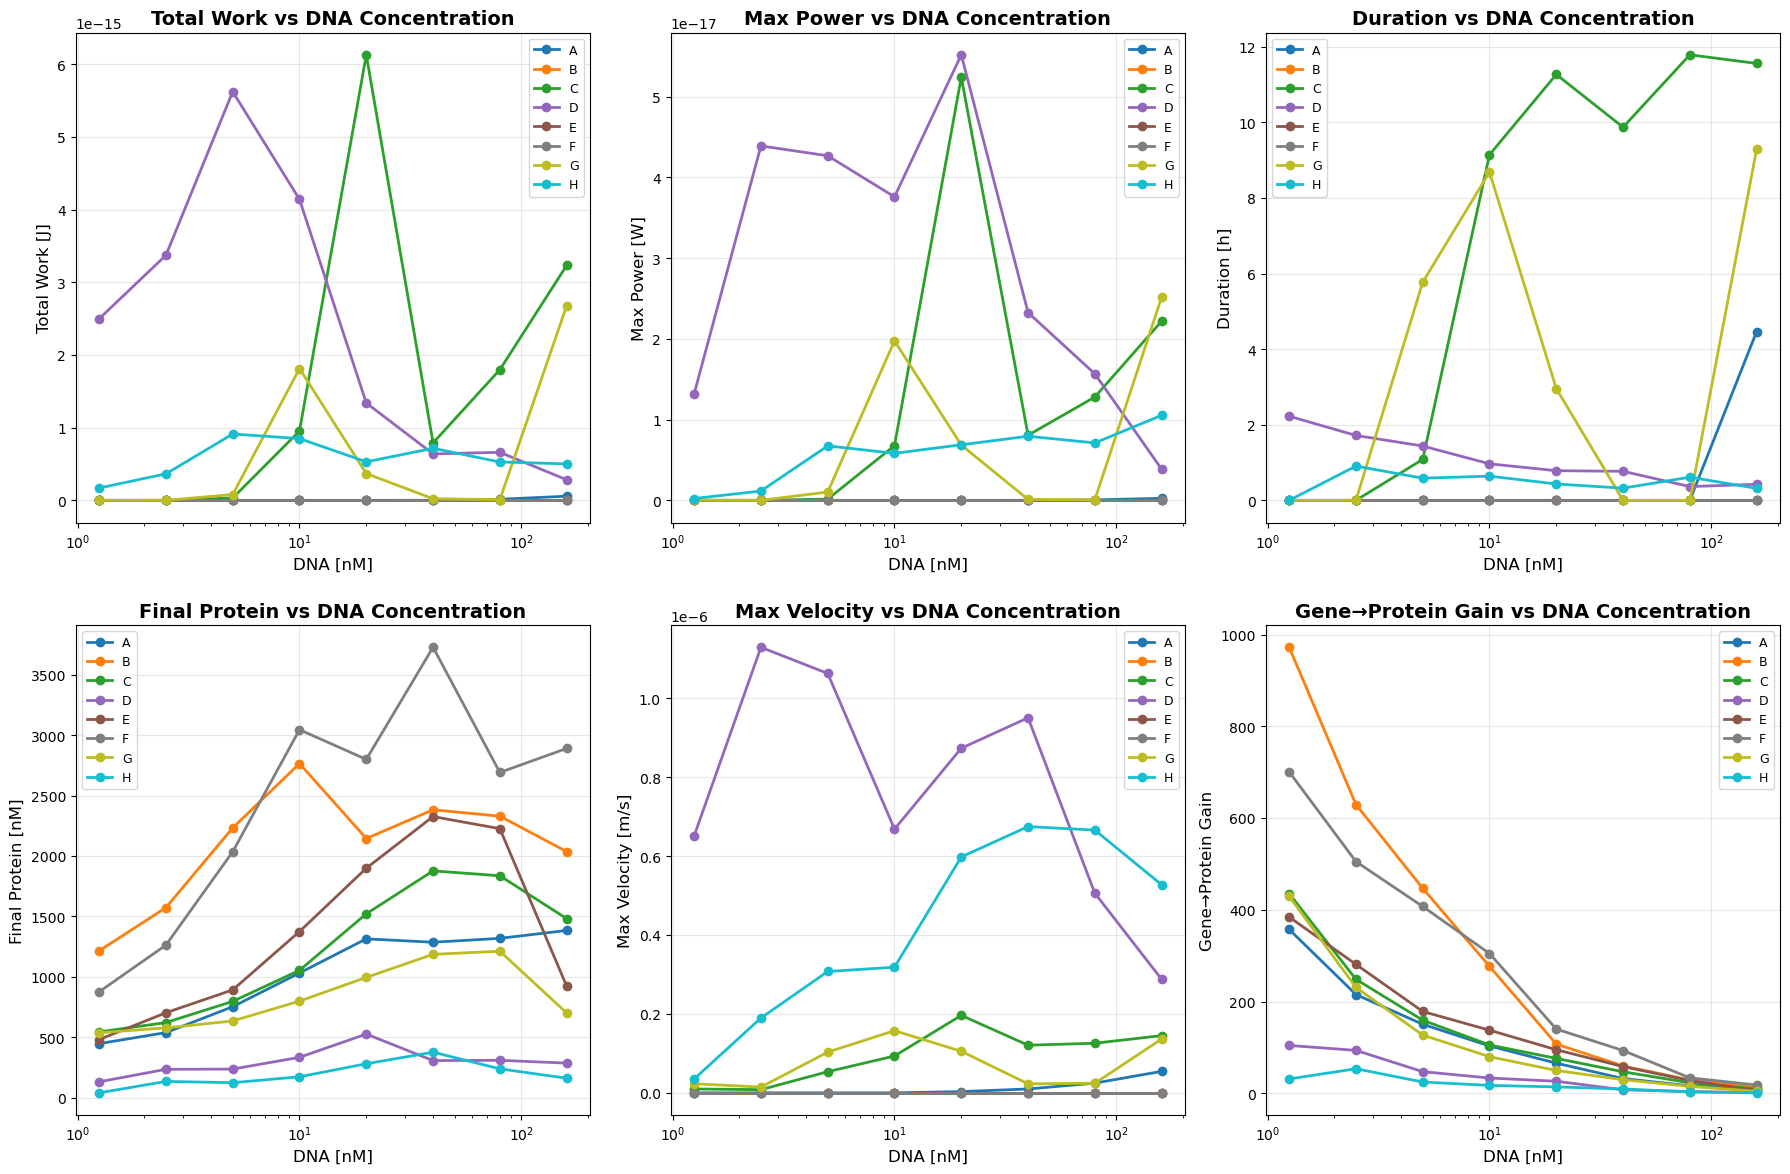

In [10]:
# Task 4: Generate plots

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create output directory for figures
import os
os.makedirs('figures', exist_ok=True)

# Color map for motors
colors = plt.cm.tab10(np.linspace(0, 1, 8))
motor_colors = dict(zip(chimeras, colors))

# 1. Curves vs DNA (all motors on each plot; log x-axis for DNA)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Total work vs DNA
ax = axes[0]
for motor in chimeras:
    motor_data = summary_per_motor_dna[summary_per_motor_dna['protein'] == motor]
    if len(motor_data) > 0:
        ax.plot(motor_data['DNA nM'], motor_data['total_work'], 
                'o-', label=motor, color=motor_colors[motor], linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('DNA [nM]', fontsize=12)
ax.set_ylabel('Total Work [J]', fontsize=12)
ax.set_title('Total Work vs DNA Concentration', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Max power vs DNA
ax = axes[1]
for motor in chimeras:
    motor_data = summary_per_motor_dna[summary_per_motor_dna['protein'] == motor]
    if len(motor_data) > 0:
        ax.plot(motor_data['DNA nM'], motor_data['max_power'], 
                'o-', label=motor, color=motor_colors[motor], linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('DNA [nM]', fontsize=12)
ax.set_ylabel('Max Power [W]', fontsize=12)
ax.set_title('Max Power vs DNA Concentration', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Duration vs DNA
ax = axes[2]
for motor in chimeras:
    motor_data = summary_per_motor_dna[summary_per_motor_dna['protein'] == motor]
    if len(motor_data) > 0:
        ax.plot(motor_data['DNA nM'], motor_data['duration_h'], 
                'o-', label=motor, color=motor_colors[motor], linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('DNA [nM]', fontsize=12)
ax.set_ylabel('Duration [h]', fontsize=12)
ax.set_title('Duration vs DNA Concentration', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Final protein vs DNA
ax = axes[3]
for motor in chimeras:
    motor_data = summary_per_motor_dna[summary_per_motor_dna['protein'] == motor]
    if len(motor_data) > 0:
        ax.plot(motor_data['DNA nM'], motor_data['prot_final_nM'], 
                'o-', label=motor, color=motor_colors[motor], linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('DNA [nM]', fontsize=12)
ax.set_ylabel('Final Protein [nM]', fontsize=12)
ax.set_title('Final Protein vs DNA Concentration', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Max velocity vs DNA
ax = axes[4]
for motor in chimeras:
    motor_data = summary_per_motor_dna[summary_per_motor_dna['protein'] == motor]
    if len(motor_data) > 0:
        ax.plot(motor_data['DNA nM'], motor_data['max_vel'], 
                'o-', label=motor, color=motor_colors[motor], linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('DNA [nM]', fontsize=12)
ax.set_ylabel('Max Velocity [m/s]', fontsize=12)
ax.set_title('Max Velocity vs DNA Concentration', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Gene to protein gain vs DNA
ax = axes[5]
for motor in chimeras:
    motor_data = summary_per_motor_dna[summary_per_motor_dna['protein'] == motor]
    if len(motor_data) > 0:
        ax.plot(motor_data['DNA nM'], motor_data['gene2prot_gain'], 
                'o-', label=motor, color=motor_colors[motor], linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('DNA [nM]', fontsize=12)
ax.set_ylabel('Gene→Protein Gain', fontsize=12)
ax.set_title('Gene→Protein Gain vs DNA Concentration', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/curves_vs_DNA.png', dpi=300, bbox_inches='tight')
plt.show()


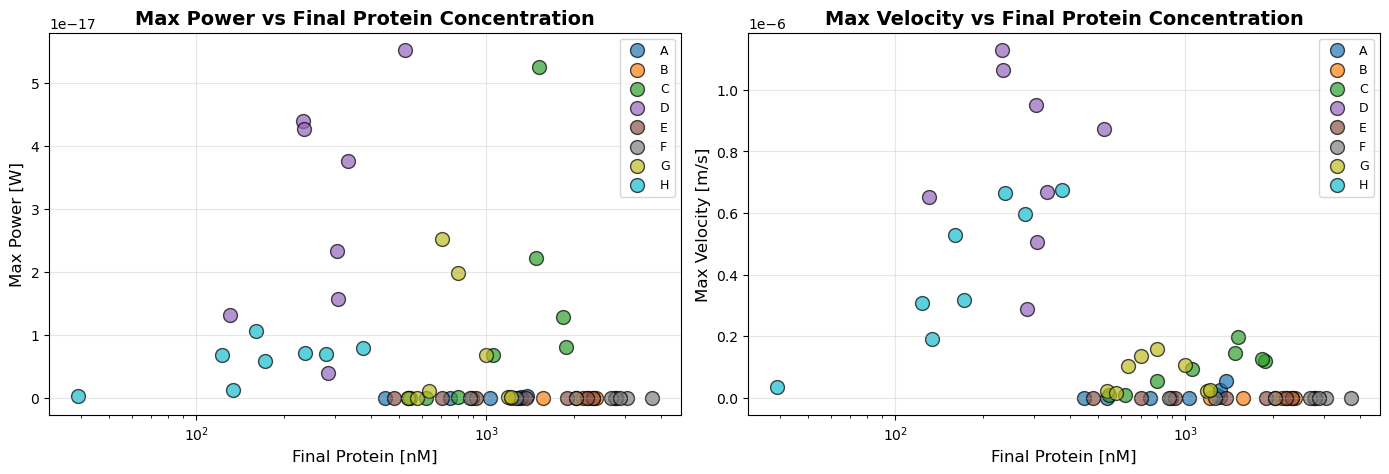

In [11]:
# 2. Power/velocity vs protein

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Max power vs final protein
ax = axes[0]
for motor in chimeras:
    motor_data = summary_per_motor_dna[summary_per_motor_dna['protein'] == motor]
    ax.scatter(motor_data['prot_final_nM'], motor_data['max_power'], 
               label=motor, color=motor_colors[motor], s=100, alpha=0.7, edgecolors='black', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Final Protein [nM]', fontsize=12)
ax.set_ylabel('Max Power [W]', fontsize=12)
ax.set_title('Max Power vs Final Protein Concentration', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Max velocity vs final protein
ax = axes[1]
for motor in chimeras:
    motor_data = summary_per_motor_dna[summary_per_motor_dna['protein'] == motor]
    ax.scatter(motor_data['prot_final_nM'], motor_data['max_vel'], 
               label=motor, color=motor_colors[motor], s=100, alpha=0.7, edgecolors='black', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Final Protein [nM]', fontsize=12)
ax.set_ylabel('Max Velocity [m/s]', fontsize=12)
ax.set_title('Max Velocity vs Final Protein Concentration', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/power_velocity_vs_protein.png', dpi=300, bbox_inches='tight')
plt.show()


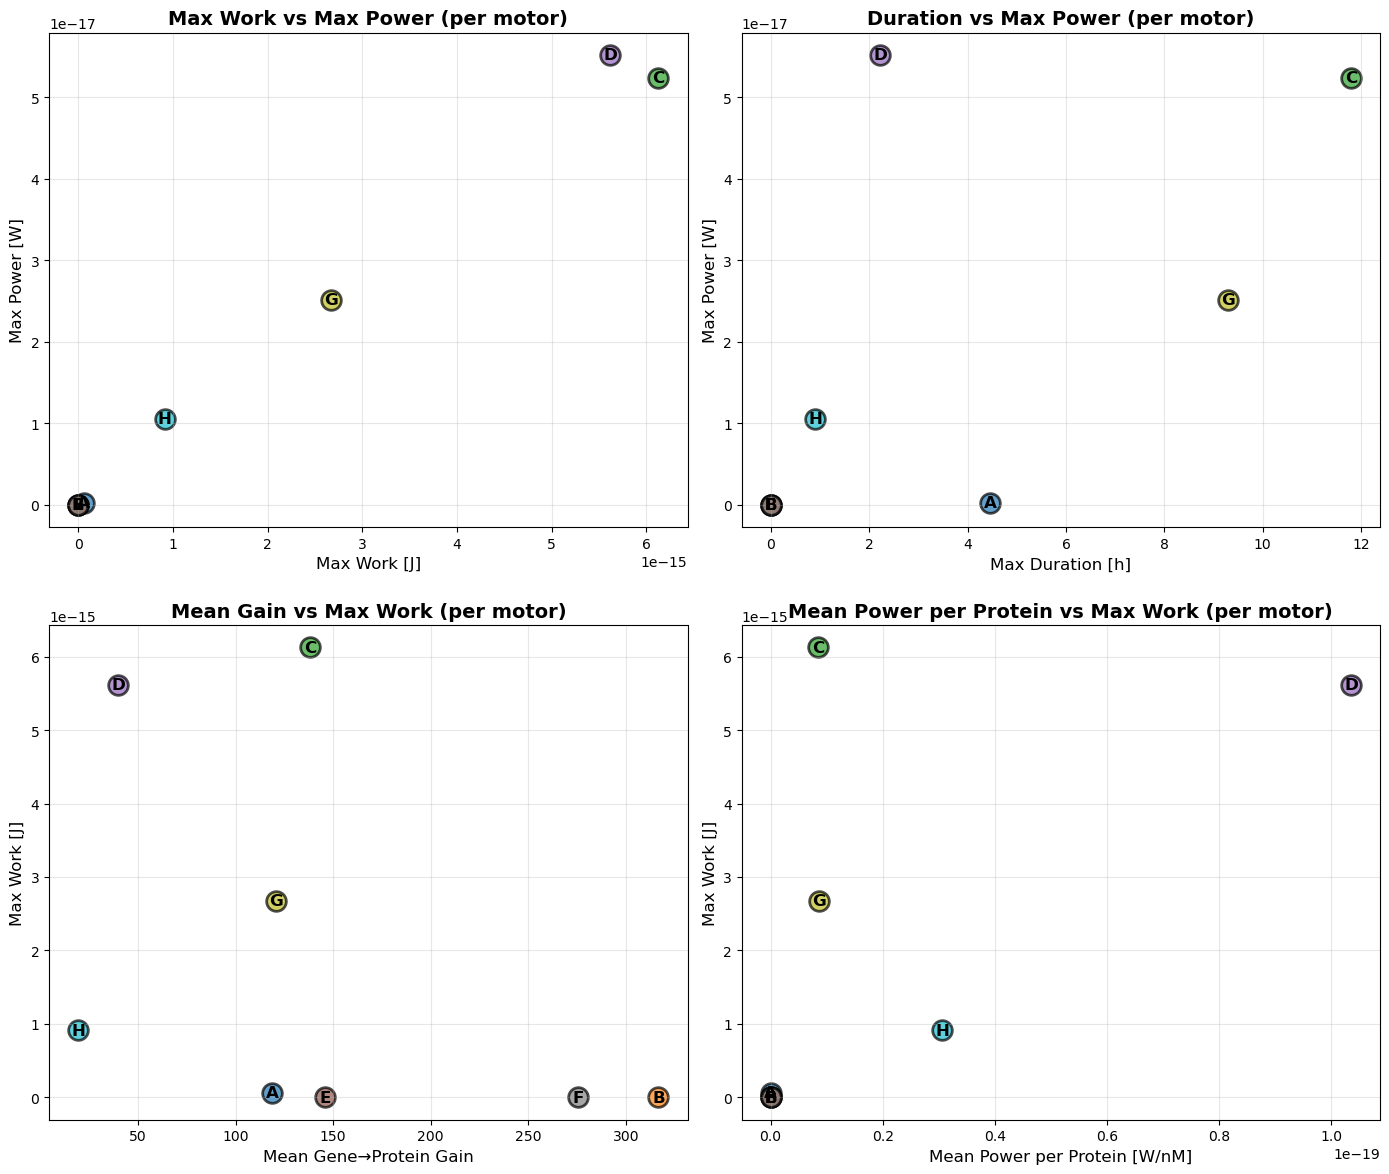

In [12]:
# 3. Scatter plots per motor

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Max work vs max power
ax = axes[0]
for motor in chimeras:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    ax.scatter(motor_row['max_work'], motor_row['max_power'], 
               color=motor_colors[motor], s=200, alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(motor, (motor_row['max_work'], motor_row['max_power']), 
                fontsize=12, fontweight='bold', ha='center', va='center')
ax.set_xlabel('Max Work [J]', fontsize=12)
ax.set_ylabel('Max Power [W]', fontsize=12)
ax.set_title('Max Work vs Max Power (per motor)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Duration vs max power
ax = axes[1]
for motor in chimeras:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    ax.scatter(motor_row['duration_max'], motor_row['max_power'], 
               color=motor_colors[motor], s=200, alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(motor, (motor_row['duration_max'], motor_row['max_power']), 
                fontsize=12, fontweight='bold', ha='center', va='center')
ax.set_xlabel('Max Duration [h]', fontsize=12)
ax.set_ylabel('Max Power [W]', fontsize=12)
ax.set_title('Duration vs Max Power (per motor)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Mean gene→protein gain vs max work
ax = axes[2]
for motor in chimeras:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    ax.scatter(motor_row['mean_gene2prot_gain'], motor_row['max_work'], 
               color=motor_colors[motor], s=200, alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(motor, (motor_row['mean_gene2prot_gain'], motor_row['max_work']), 
                fontsize=12, fontweight='bold', ha='center', va='center')
ax.set_xlabel('Mean Gene→Protein Gain', fontsize=12)
ax.set_ylabel('Max Work [J]', fontsize=12)
ax.set_title('Mean Gain vs Max Work (per motor)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Mean power per protein vs max work
ax = axes[3]
for motor in chimeras:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    ax.scatter(motor_row['mean_power_per_prot'], motor_row['max_work'], 
               color=motor_colors[motor], s=200, alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(motor, (motor_row['mean_power_per_prot'], motor_row['max_work']), 
                fontsize=12, fontweight='bold', ha='center', va='center')
ax.set_xlabel('Mean Power per Protein [W/nM]', fontsize=12)
ax.set_ylabel('Max Work [J]', fontsize=12)
ax.set_title('Mean Power per Protein vs Max Work (per motor)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/scatter_plots_per_motor.png', dpi=300, bbox_inches='tight')
plt.show()


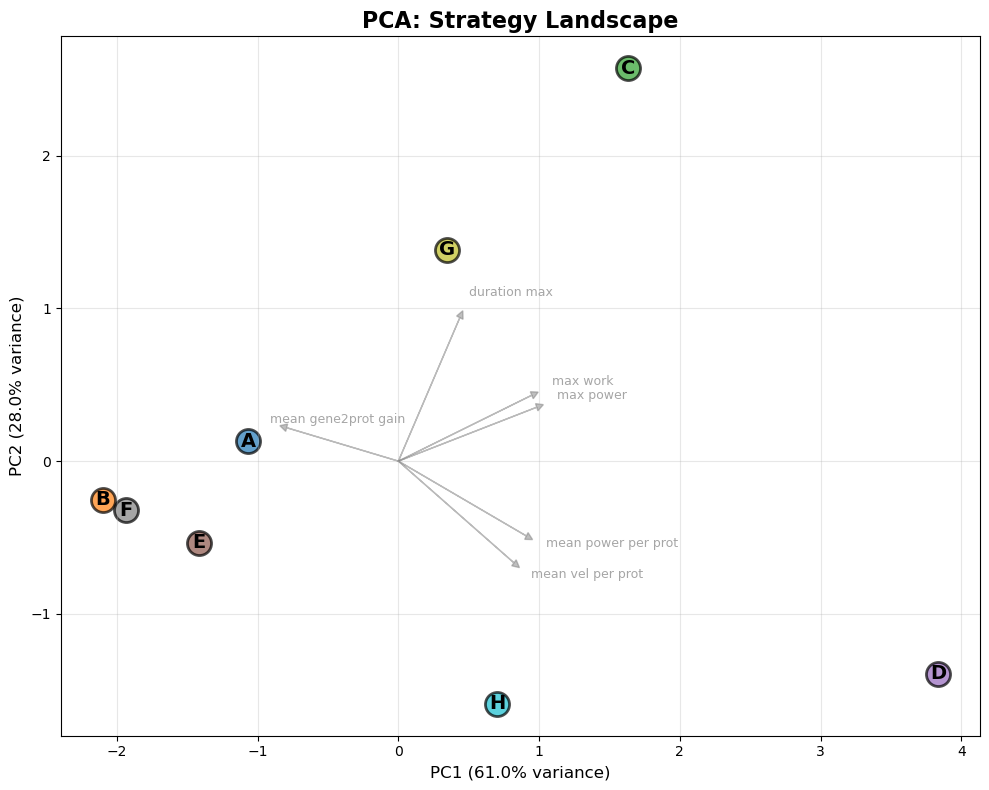

PCA explained variance: PC1=61.04%, PC2=28.04%
Total explained variance: 89.08%


In [13]:
# 4. PCA analysis

from sklearn.decomposition import PCA

# Prepare features for PCA
features = ['max_work', 'max_power', 'duration_max', 'mean_gene2prot_gain', 
            'mean_power_per_prot', 'mean_vel_per_prot']
X = motor_summary[features].fillna(0).values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA results to motor_summary
motor_summary['PC1'] = X_pca[:, 0]
motor_summary['PC2'] = X_pca[:, 1]

# Plot PCA
fig, ax = plt.subplots(figsize=(10, 8))
for motor in chimeras:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    ax.scatter(motor_row['PC1'], motor_row['PC2'], 
               color=motor_colors[motor], s=300, alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(motor, (motor_row['PC1'], motor_row['PC2']), 
                fontsize=14, fontweight='bold', ha='center', va='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA: Strategy Landscape', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add feature loadings
feature_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, feature in enumerate(features):
    ax.arrow(0, 0, feature_loadings[i, 0], feature_loadings[i, 1], 
             head_width=0.05, head_length=0.05, fc='gray', ec='gray', alpha=0.5)
    ax.text(feature_loadings[i, 0]*1.15, feature_loadings[i, 1]*1.15, 
            feature.replace('_', ' '), fontsize=9, color='gray', alpha=0.7)

plt.tight_layout()
plt.savefig('figures/PCA_strategy_landscape.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")


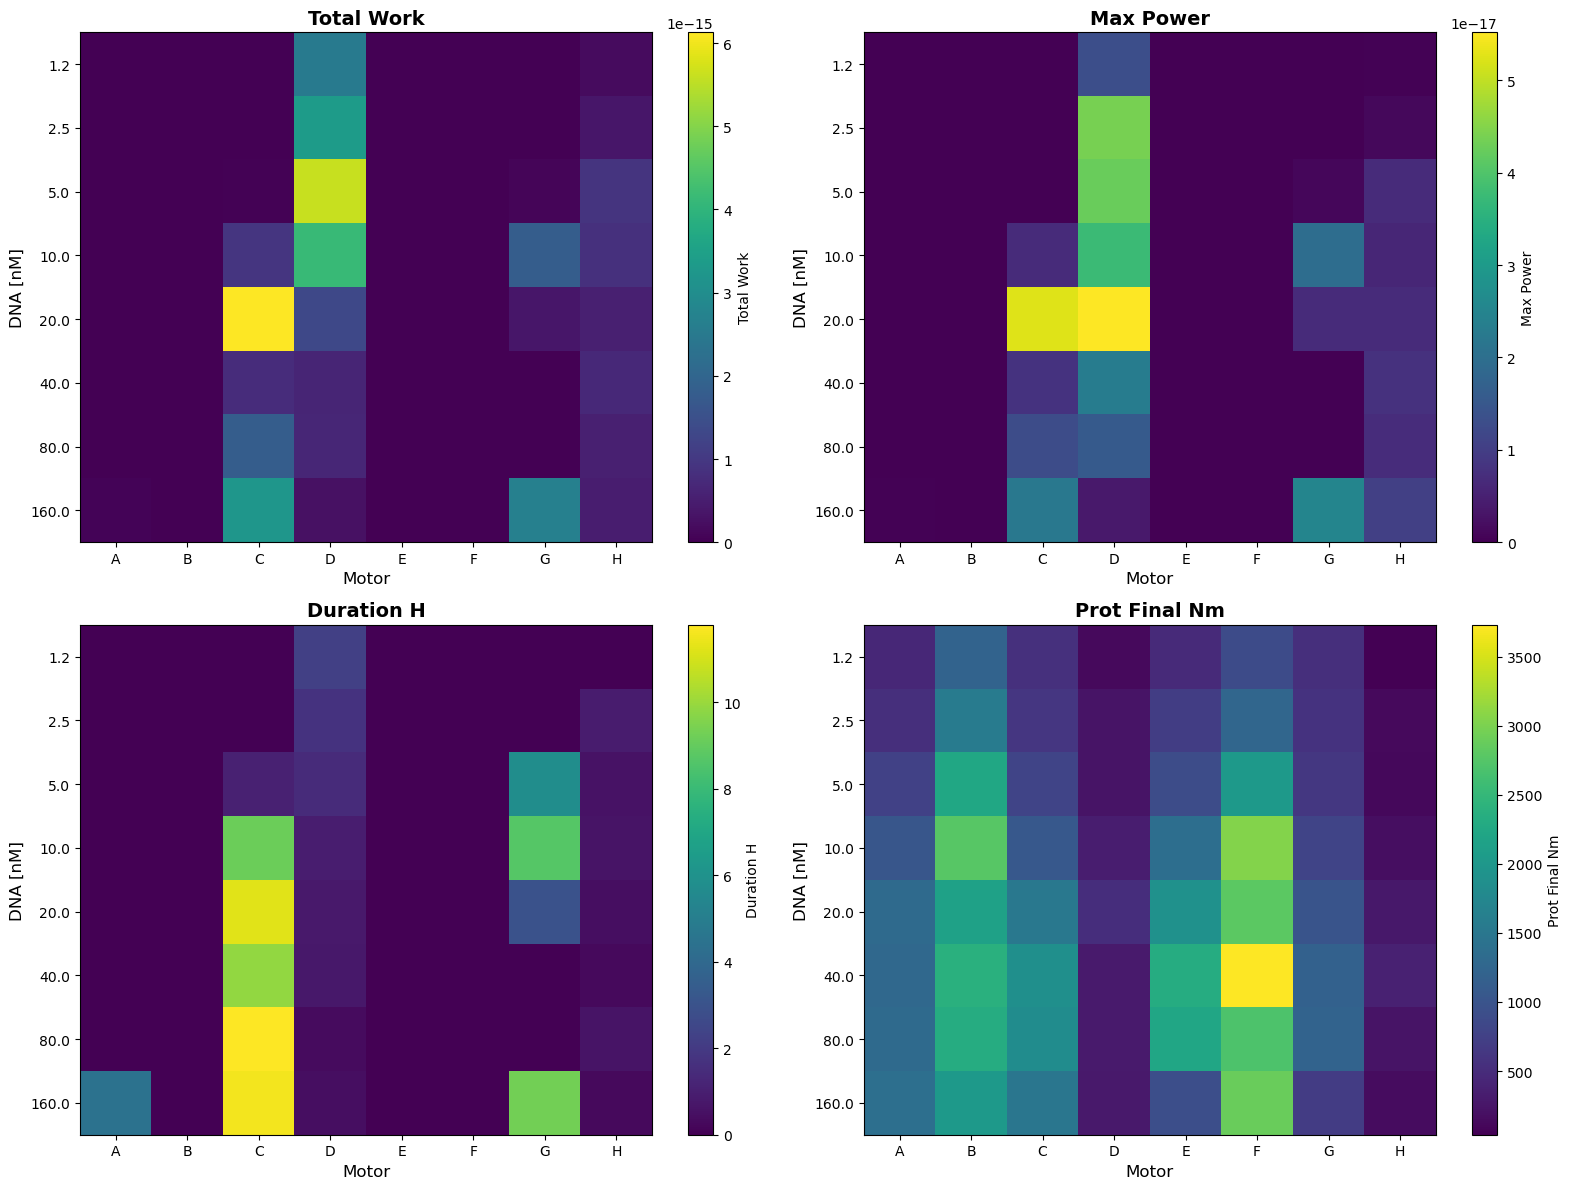

In [14]:
# 5. Heatmaps

metrics_for_heatmap = ['total_work', 'max_power', 'duration_h', 'prot_final_nM']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics_for_heatmap):
    # Create pivot table
    pivot = summary_per_motor_dna.pivot_table(
        index='DNA nM', 
        columns='protein', 
        values=metric,
        aggfunc='mean'
    )
    
    # Reorder columns to match chimeras order
    pivot = pivot[chimeras]
    
    # Plot heatmap
    ax = axes[idx]
    im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', interpolation='nearest')
    
    # Set ticks
    ax.set_xticks(range(len(chimeras)))
    ax.set_xticklabels(chimeras)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{dna:.1f}" for dna in pivot.index])
    
    ax.set_xlabel('Motor', fontsize=12)
    ax.set_ylabel('DNA [nM]', fontsize=12)
    ax.set_title(f'{metric.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label=metric.replace('_', ' ').title())

plt.tight_layout()
plt.savefig('figures/heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()


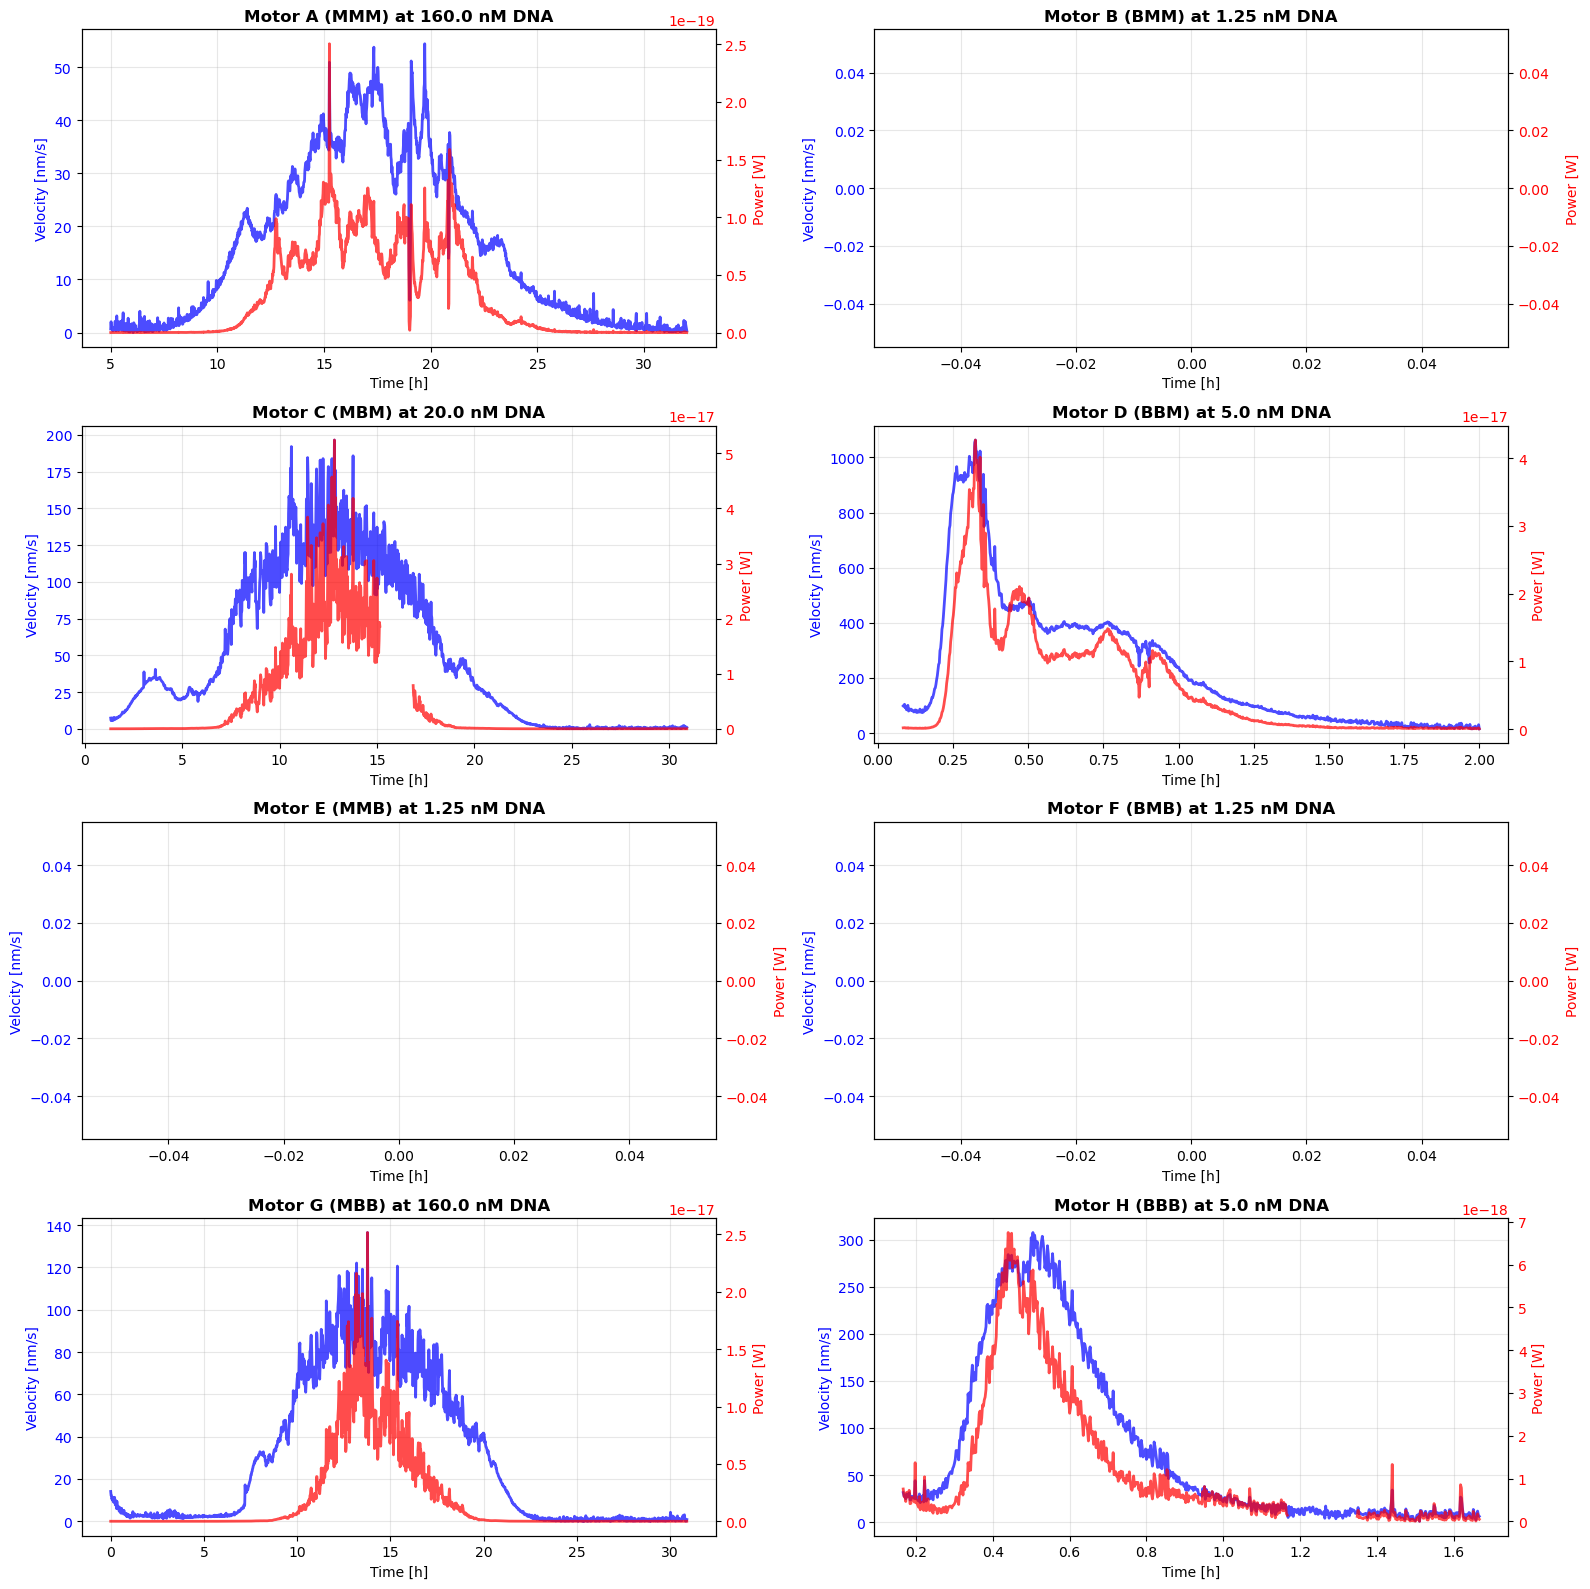

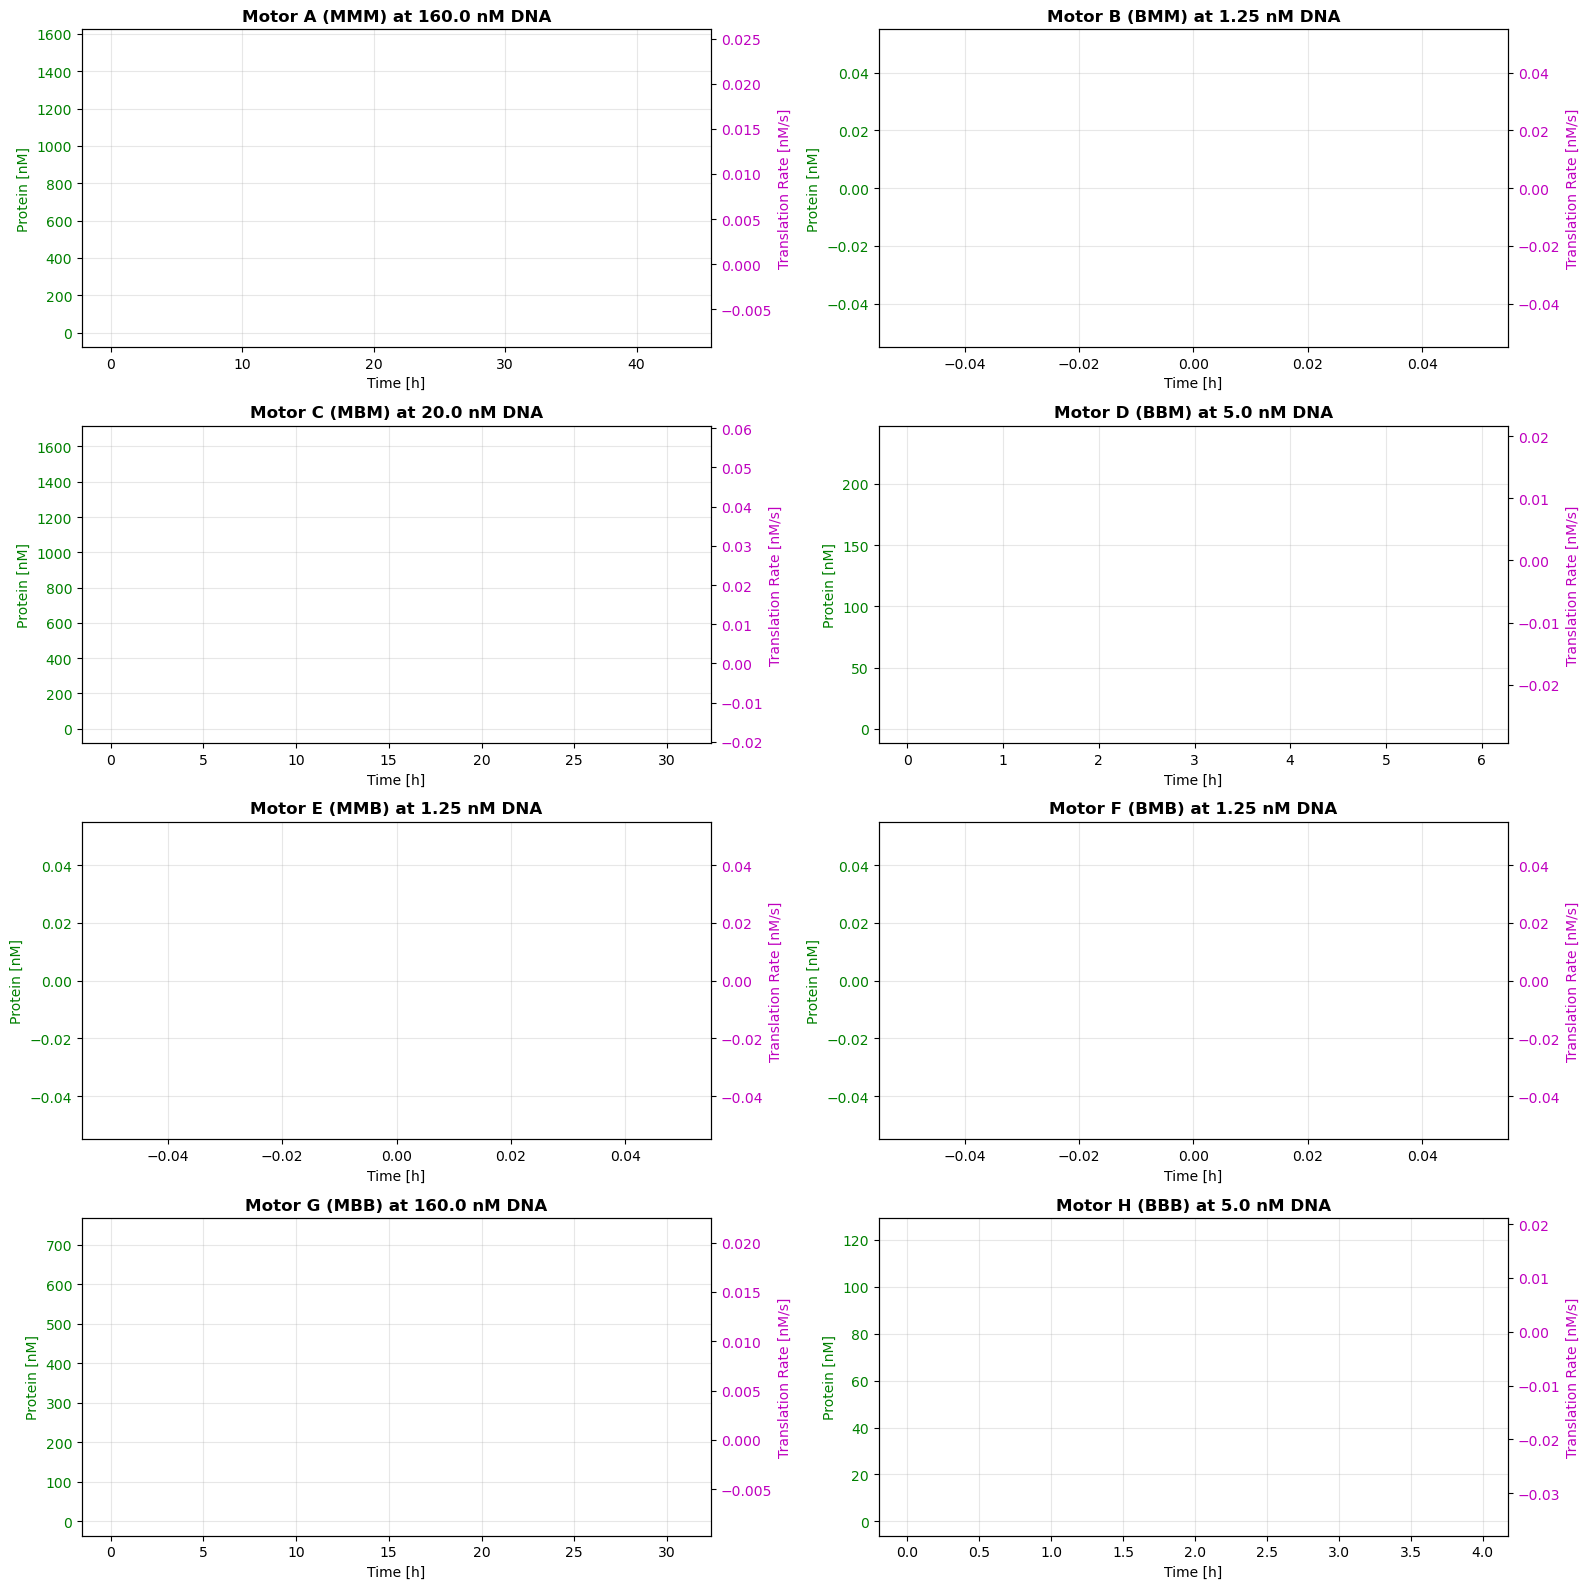

In [15]:
# 6. Time series at best DNA (DNA_at_max_work)

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for idx, motor in enumerate(chimeras):
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    best_dna = motor_row['DNA_at_max_work']
    
    # Get data for this motor at best DNA
    motor_dna_data = df_chimeras[
        (df_chimeras['protein'] == motor) & 
        (df_chimeras['DNA nM'] == best_dna)
    ].copy()
    
    if len(motor_dna_data) == 0:
        continue
    
    # Get time in hours
    if 'time (h)' in motor_dna_data.columns:
        time_h = motor_dna_data['time (h)'].values
    elif 'Time_h' in motor_dna_data.columns:
        time_h = motor_dna_data['Time_h'].values
    else:
        time_h = motor_dna_data['time (s)'].values / 3600
    
    # Sort by time
    sort_idx = np.argsort(time_h)
    time_h = time_h[sort_idx]
    
    ax = axes[idx]
    
    # Plot velocity
    if 'velocity magnitude [m/s]_mean' in motor_dna_data.columns:
        vel = motor_dna_data['velocity magnitude [m/s]_mean'].values[sort_idx]
        ax.plot(time_h, vel * 1e9, 'b-', linewidth=2, label='Velocity (nm/s)', alpha=0.7)
    
    # Plot power
    if 'power [W]_mean' in motor_dna_data.columns:
        power = motor_dna_data['power [W]_mean'].values[sort_idx]
        ax2 = ax.twinx()
        ax2.plot(time_h, power, 'r-', linewidth=2, label='Power (W)', alpha=0.7)
        ax2.set_ylabel('Power [W]', fontsize=10, color='r')
        ax2.tick_params(axis='y', labelcolor='r')
    
    ax.set_xlabel('Time [h]', fontsize=10)
    ax.set_ylabel('Velocity [nm/s]', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title(f'Motor {motor} ({motor_row["modules"]}) at {best_dna} nM DNA', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/time_series_velocity_power.png', dpi=300, bbox_inches='tight')
plt.show()

# Separate plot for protein and translation rate
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for idx, motor in enumerate(chimeras):
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    best_dna = motor_row['DNA_at_max_work']
    
    # Get data for this motor at best DNA
    motor_dna_data = df_chimeras[
        (df_chimeras['protein'] == motor) & 
        (df_chimeras['DNA nM'] == best_dna)
    ].copy()
    
    if len(motor_dna_data) == 0:
        continue
    
    # Get time in hours
    if 'time (h)' in motor_dna_data.columns:
        time_h = motor_dna_data['time (h)'].values
    elif 'Time_h' in motor_dna_data.columns:
        time_h = motor_dna_data['Time_h'].values
    else:
        time_h = motor_dna_data['time (s)'].values / 3600
    
    # Sort by time
    sort_idx = np.argsort(time_h)
    time_h = time_h[sort_idx]
    
    ax = axes[idx]
    
    # Plot protein concentration
    if 'Protein Concentration_nM' in motor_dna_data.columns:
        prot = motor_dna_data['Protein Concentration_nM'].values[sort_idx]
        ax.plot(time_h, prot, 'g-', linewidth=2, label='Protein [nM]', alpha=0.7)
    
    # Plot translation rate
    if 'Translation Rate [nM/s]' in motor_dna_data.columns:
        trans_rate = motor_dna_data['Translation Rate [nM/s]'].values[sort_idx]
        ax2 = ax.twinx()
        ax2.plot(time_h, trans_rate, 'm-', linewidth=2, label='Translation Rate [nM/s]', alpha=0.7)
        ax2.set_ylabel('Translation Rate [nM/s]', fontsize=10, color='m')
        ax2.tick_params(axis='y', labelcolor='m')
    
    ax.set_xlabel('Time [h]', fontsize=10)
    ax.set_ylabel('Protein [nM]', fontsize=10, color='g')
    ax.tick_params(axis='y', labelcolor='g')
    ax.set_title(f'Motor {motor} ({motor_row["modules"]}) at {best_dna} nM DNA', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/time_series_protein_translation.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
# Task 5: Modularity vs Epistasis Analysis

print("="*80)
print("MODULARITY vs EPISTASIS ANALYSIS")
print("="*80)

# Identify active vs dead motors
dead_threshold_work = 1e-15  # Very low threshold for "dead"
dead_threshold_power = 1e-15

print("\n1. ACTIVE vs DEAD MOTORS:")
print("-" * 80)
for motor in chimeras:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    modules = motor_row['modules']
    max_work = motor_row['max_work']
    max_power = motor_row['max_power']
    
    status = "DEAD" if (max_work < dead_threshold_work and max_power < dead_threshold_power) else "ACTIVE"
    print(f"Motor {motor} ({modules}): {status} | Max Work: {max_work:.2e} J | Max Power: {max_power:.2e} W")

# Analyze effect of single B substitutions
print("\n2. EFFECT OF SINGLE B SUBSTITUTIONS:")
print("-" * 80)
baseline = motor_summary[motor_summary['protein'] == 'A'].iloc[0]  # MMM baseline

single_B_motors = ['B', 'C', 'E']  # BMM, MBM, MMB
for motor in single_B_motors:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    modules = motor_row['modules']
    pos = modules.index('B') + 1
    
    work_ratio = motor_row['max_work'] / baseline['max_work'] if baseline['max_work'] > 0 else 0
    power_ratio = motor_row['max_power'] / baseline['max_power'] if baseline['max_power'] > 0 else 0
    
    print(f"Motor {motor} ({modules}): B at position {pos}")
    print(f"  Work ratio vs MMM: {work_ratio:.3f}")
    print(f"  Power ratio vs MMM: {power_ratio:.3f}")
    print(f"  Status: {'DEAD' if work_ratio < 0.01 else 'ACTIVE'}")

# Analyze multi-B combinations
print("\n3. MULTI-B COMBINATIONS (EPISTASIS):")
print("-" * 80)
multi_B_motors = ['D', 'F', 'G', 'H']  # BBM, BMB, MBB, BBB
for motor in multi_B_motors:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    modules = motor_row['modules']
    B_count = motor_row['B_count']
    
    work_ratio = motor_row['max_work'] / baseline['max_work'] if baseline['max_work'] > 0 else 0
    power_ratio = motor_row['max_power'] / baseline['max_power'] if baseline['max_power'] > 0 else 0
    
    print(f"Motor {motor} ({modules}): {B_count} B modules")
    print(f"  Work ratio vs MMM: {work_ratio:.3f}")
    print(f"  Power ratio vs MMM: {power_ratio:.3f}")
    print(f"  Status: {'DEAD' if work_ratio < 0.01 else 'ACTIVE'}")

# Simple linear model for epistasis (optional)
print("\n4. LINEAR MODEL FOR EPISTASIS (max_work):")
print("-" * 80)
from sklearn.linear_model import LinearRegression

# Encode positions as binary (M=0, B=1)
X_epistasis = []
y_epistasis = []
for motor in chimeras:
    motor_row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    pos1 = 1 if motor_row['pos1'] == 'B' else 0
    pos2 = 1 if motor_row['pos2'] == 'B' else 0
    pos3 = 1 if motor_row['pos3'] == 'B' else 0
    
    X_epistasis.append([pos1, pos2, pos3, pos1*pos2, pos1*pos3, pos2*pos3, pos1*pos2*pos3])
    y_epistasis.append(motor_row['max_work'])

X_epistasis = np.array(X_epistasis)
y_epistasis = np.array(y_epistasis)

# Fit model
model = LinearRegression()
model.fit(X_epistasis, y_epistasis)

feature_names = ['pos1', 'pos2', 'pos3', 'pos1:pos2', 'pos1:pos3', 'pos2:pos3', 'pos1:pos2:pos3']
print("Coefficients:")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name}: {coef:.2e}")
print(f"  Intercept: {model.intercept_:.2e}")
print(f"  R²: {model.score(X_epistasis, y_epistasis):.3f}")

# Identify significant interactions (epistasis)
print("\n5. EVIDENCE FOR EPISTASIS:")
print("-" * 80)
interaction_coefs = dict(zip(feature_names[3:], model.coef_[3:]))
for interaction, coef in interaction_coefs.items():
    if abs(coef) > abs(model.coef_[:3]).max() * 0.1:  # Interaction > 10% of main effect
        print(f"  {interaction}: {coef:.2e} (significant interaction)")


MODULARITY vs EPISTASIS ANALYSIS

1. ACTIVE vs DEAD MOTORS:
--------------------------------------------------------------------------------
Motor A (MMM): DEAD | Max Work: 5.71e-17 J | Max Power: 2.51e-19 W
Motor B (BMM): DEAD | Max Work: 0.00e+00 J | Max Power: 0.00e+00 W
Motor C (MBM): ACTIVE | Max Work: 6.13e-15 J | Max Power: 5.24e-17 W
Motor D (BBM): ACTIVE | Max Work: 5.62e-15 J | Max Power: 5.52e-17 W
Motor E (MMB): DEAD | Max Work: 0.00e+00 J | Max Power: 0.00e+00 W
Motor F (BMB): DEAD | Max Work: 0.00e+00 J | Max Power: 0.00e+00 W
Motor G (MBB): ACTIVE | Max Work: 2.68e-15 J | Max Power: 2.52e-17 W
Motor H (BBB): DEAD | Max Work: 9.13e-16 J | Max Power: 1.05e-17 W

2. EFFECT OF SINGLE B SUBSTITUTIONS:
--------------------------------------------------------------------------------
Motor B (BMM): B at position 1
  Work ratio vs MMM: 0.000
  Power ratio vs MMM: 0.000
  Status: DEAD
Motor C (MBM): B at position 2
  Work ratio vs MMM: 107.312
  Power ratio vs MMM: 209.315
  Statu

In [17]:
# Task 6: Strategy Classification

print("="*80)
print("STRATEGY CLASSIFICATION")
print("="*80)

# Define thresholds for classification
work_threshold_high = motor_summary['max_work'].quantile(0.67)
work_threshold_low = motor_summary['max_work'].quantile(0.33)
duration_threshold_high = motor_summary['duration_max'].quantile(0.67)
duration_threshold_low = motor_summary['duration_max'].quantile(0.33)
power_per_prot_threshold_high = motor_summary['mean_power_per_prot'].quantile(0.67)

def classify_strategy(row):
    """Classify motor strategy based on metrics"""
    max_work = row['max_work']
    duration = row['duration_max']
    power_per_prot = row['mean_power_per_prot']
    
    # Dead/weak
    if max_work < dead_threshold_work or row['max_power'] < dead_threshold_power:
        return "dead/weak"
    
    # High-work, long-duration
    if max_work >= work_threshold_high and duration >= duration_threshold_high:
        return "long-duration, high-work"
    
    # High-efficiency, short-duration burst
    if power_per_prot >= power_per_prot_threshold_high and duration < duration_threshold_high:
        return "short burst, high efficiency"
    
    # Medium categories
    if max_work >= work_threshold_high:
        return "high-work, variable duration"
    if duration >= duration_threshold_high:
        return "long-duration, moderate work"
    
    return "moderate"

# Add strategy classification
motor_summary['strategy'] = motor_summary.apply(classify_strategy, axis=1)

# Print summary table
print("\nMOTOR STRATEGY SUMMARY:")
print("="*80)
print(f"{'Motor':<6} {'Modules':<6} {'DNA@max_work':<12} {'Max Work':<12} {'DNA@max_power':<14} {'Max Power':<12} {'Duration':<10} {'Mean Gain':<12} {'Power/Prot':<12} {'Strategy':<30}")
print("-"*80)

for motor in chimeras:
    row = motor_summary[motor_summary['protein'] == motor].iloc[0]
    print(f"{row['protein']:<6} {row['modules']:<6} {row['DNA_at_max_work']:<12.1f} {row['max_work']:<12.2e} "
          f"{row['DNA_at_max_power']:<14.1f} {row['max_power']:<12.2e} {row['duration_max']:<10.2f} "
          f"{row['mean_gene2prot_gain']:<12.3f} {row['mean_power_per_prot']:<12.2e} {row['strategy']:<30}")

# Group by strategy
print("\n\nSTRATEGY GROUPS:")
print("="*80)
for strategy in motor_summary['strategy'].unique():
    motors_in_strategy = motor_summary[motor_summary['strategy'] == strategy]['protein'].tolist()
    print(f"\n{strategy.upper()}:")
    print(f"  Motors: {', '.join(motors_in_strategy)}")
    strategy_data = motor_summary[motor_summary['strategy'] == strategy]
    print(f"  Mean max work: {strategy_data['max_work'].mean():.2e} J")
    print(f"  Mean max power: {strategy_data['max_power'].mean():.2e} W")
    print(f"  Mean duration: {strategy_data['duration_max'].mean():.2f} h")
    print(f"  Mean gene→protein gain: {strategy_data['mean_gene2prot_gain'].mean():.3f}")

# Save summary tables
summary_per_motor_dna.to_csv('figures/summary_per_motor_dna.csv', index=False)
motor_summary.to_csv('figures/motor_summary.csv', index=False)

print("\n\nSummary tables saved to:")
print("  - figures/summary_per_motor_dna.csv")
print("  - figures/motor_summary.csv")


STRATEGY CLASSIFICATION

MOTOR STRATEGY SUMMARY:
Motor  Modules DNA@max_work Max Work     DNA@max_power  Max Power    Duration   Mean Gain    Power/Prot   Strategy                      
--------------------------------------------------------------------------------
A      MMM    160.0        5.71e-17     160.0          2.51e-19     4.47       118.658      2.82e-23     dead/weak                     
B      BMM    1.2          0.00e+00     1.2            0.00e+00     0.00       316.730      0.00e+00     dead/weak                     
C      MBM    20.0         6.13e-15     20.0           5.24e-17     11.79      137.980      8.42e-21     dead/weak                     
D      BBM    5.0          5.62e-15     20.0           5.52e-17     2.23       39.752       1.03e-19     dead/weak                     
E      MMB    1.2          0.00e+00     1.2            0.00e+00     0.00       146.008      0.00e+00     dead/weak                     
F      BMB    1.2          0.00e+00     1.2          

## Summary of Key Findings

### Active vs Dead Motors
- **Active motors**: Motors that produce measurable work and power
- **Dead motors**: Motors with essentially zero work/power output

### Modularity vs Epistasis
- **Single B substitutions** (BMM, MBM, MMB) may be lethal or severely impaired
- **Multi-B combinations** (BBM, MBB, BBB) can rescue function → evidence of epistasis
- Position-specific effects: Different positions (ATPase core, binding interface, stalk) have different impacts

### Strategy Classification
Motors can be classified into distinct behavioral strategies:
1. **Long-duration, high-work**: Sustained motion over extended periods
2. **Short burst, high efficiency**: Brief but intense motion
3. **Dead/weak**: Non-functional or minimal activity

### Trade-offs
- **Expression vs Output**: Some motors have high gene→protein gain but low mechanical output
- **Duration vs Power**: Trade-off between sustained motion and peak power
- **Efficiency vs Total Work**: Some motors are efficient (high power per protein) but produce less total work

### Strategy Landscape (PCA)
The PCA analysis reveals clustering of motors into strategy families based on:
- Max work, max power, duration
- Gene→protein gain
- Power per protein, velocity per protein
